In [3]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

import pandas as pd
import importlib

# 1️⃣ reload modules
import data.indicators as ind
import data.data_loader as dl
import portfolio.portfolio as pf
import strategy.single_factor_strategy as st
import strategy.single_factor_full_strategy as st_full
import strategy.single_factor_full_stploss_strategy as st_stp
import strategy.single_factor_abs_stp_strategy as abs_stp
import engine.instant_engine as eng1
import engine.delay_engine as eng2
import engine.instant_full_engine as eng3
import engine.delay_full_engine as eng4
import analysis.plot_analysis as ana

importlib.reload(ind)
importlib.reload(dl)
importlib.reload(pf)
importlib.reload(st)
importlib.reload(eng1)
importlib.reload(eng2)
importlib.reload(eng3)
importlib.reload(eng4)
importlib.reload(st_full)
importlib.reload(st_stp)
importlib.reload(abs_stp)
importlib.reload(ana)

# 2️⃣ re-import ALL classes (关键！！)
from data.indicators import pct_change, trend_score, rsrs, rsrs_std, trend_score_avg_price
from data.indicators import momentum_open, momentum_close, momentum_avg, trend_score_riskoff
from data.indicators import sharpe_momentum
from data.indicator_xhs import trend_score_xhs, final_factor_xhs
from data.data_loader import load_etf_data

from portfolio.portfolio import Portfolio

from strategy.single_factor_strategy import SingleFactorStrategy
from strategy.single_factor_full_strategy import SingleFactorFullStrategy
from strategy.single_factor_full_stploss_strategy import SingleFactorFullStpLossStrategy
from strategy.single_factor_abs_stp_strategy import SingleFactorAbsStpStrategy

from engine.instant_full_engine import InstantFullEngine
from engine.delay_full_engine import DelayFullEngine

In [2]:
# FILE_PATH_ETF = "data/datas/ETF日频数据/etf_panel.pkl"
FILE_PATH_ETF = "data/datas/轮动池6/etf_panel.pkl"
df_etf = load_etf_data(FILE_PATH_ETF)

# factor_df = trend_score(df_etf, window=25) # CAGR 0.3331
# factor_df = trend_score_riskoff(df_etf, window=25, vol_window=252) # CAGR 0.3392
# factor_df = trend_score_xhs(df_etf, window=120)
factor_df = final_factor_xhs(df_etf)
# factor_df = sharpe_momentum(df_etf, ret_window=20, vol_window=25) # CAGR 0.2741
# factor_df = momentum_close(df_etf, win_length=25) # CCAGR 0.3212
# factor_df = momentum_open(df_etf, win_length=20) # CAGR 0.2961
# factor_df = momentum_avg(df_etf, win_length=20) # CAGR 0.2001
# factor_df = trend_score_avg_price(df_etf, window=20) # CAGR 0.3057

cash = 1_000_000
portfolio = Portfolio(cash=cash, etf_cost_rate=0.0000_5, etf_slippage=0.00_05, etf_min_cost=0.0)

strategy = SingleFactorFullStrategy(factor_df=factor_df)
# strategy = SingleFactorAbsStpStrategy(factor_df, dd_breach_days=3, cooldown_days=3, dd_window=252, abs_dd_threshold=0.10)
# strategy = SingleFactorFullStpLossStrategy(factor_df=factor_df, max_drawdown_threshold=0.95, dd_window=252, 
#                                            dd_breach_days=3, cooldown_days=3)

engine = DelayFullEngine(
    data=df_etf,
    strategy=strategy,
    portfolio=portfolio,
    start="2015-01-01",
    end="2026-05-31"
)

result = engine.run()

2015-01-05 00:00:00
今天因子数据缺失
2015-01-06 00:00:00
今天因子数据缺失
2015-01-07 00:00:00
今天因子数据缺失
2015-01-08 00:00:00
今天因子数据缺失
2015-01-09 00:00:00
今天因子数据缺失
2015-01-12 00:00:00
今天因子数据缺失
2015-01-13 00:00:00
今天因子数据缺失
2015-01-14 00:00:00
今天因子数据缺失
2015-01-15 00:00:00
今天因子数据缺失
2015-01-16 00:00:00
今天因子数据缺失
2015-01-19 00:00:00
今天因子数据缺失
2015-01-20 00:00:00
今天因子数据缺失
2015-01-21 00:00:00
今天因子数据缺失
2015-01-22 00:00:00
今天因子数据缺失
2015-01-23 00:00:00
今天因子数据缺失
2015-01-26 00:00:00
今天因子数据缺失
2015-01-27 00:00:00
今天因子数据缺失
2015-01-28 00:00:00
今天因子数据缺失
2015-01-29 00:00:00
今天因子数据缺失
2015-01-30 00:00:00
今天因子数据缺失
2015-02-02 00:00:00
今天因子数据缺失
2015-02-03 00:00:00
今天因子数据缺失
2015-02-04 00:00:00
今天因子数据缺失
2015-02-05 00:00:00
今天因子数据缺失
2015-02-06 00:00:00
今天因子数据缺失
2015-02-09 00:00:00
今天因子数据缺失
2015-02-10 00:00:00
今天因子数据缺失
2015-02-11 00:00:00
今天因子数据缺失
2015-02-12 00:00:00
今天因子数据缺失
2015-02-13 00:00:00
今天因子数据缺失
2015-02-16 00:00:00
今天因子数据缺失
2015-02-17 00:00:00
今天因子数据缺失
2015-02-25 00:00:00
今天因子数据缺失
2015-02-26 00:00:00
今天因子数据缺失
2015-02-27 00:

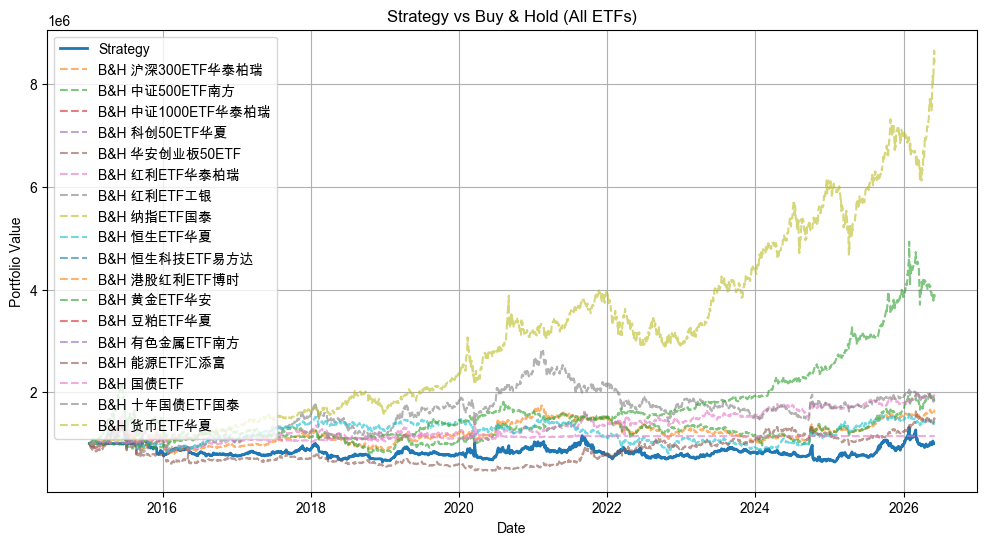

In [3]:
from analysis.plot_analysis import plot_strategy_vs_buyhold
plot_strategy_vs_buyhold(df_etf=df_etf, result=result, initial_cash=cash)

In [51]:
from analysis.plot_analysis import  performance_metrics, build_trade_pairs

metrics = performance_metrics(result)

for k, v in metrics.items():
    print(k, round(v, 4))

CAGR 0.0061
Volatility 0.3175
Sharpe 0.179
Max Drawdown -0.4827
Calmar 0.0126


In [52]:
pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')

trade_log = portfolio.trade_history
df = pd.DataFrame(trade_log)
pnl_df = build_trade_pairs(df)
pnl_df

,etf,entry_time,exit_time,direction,quantity,entry_price,exit_price,holding_days,pnl,return
0,中证1000ETF华泰柏瑞,2021-11-30,2021-12-03,LONG,265100,2.996397,2.991104,3,-1403.373125,-0.001767
1,中证1000ETF华泰柏瑞,2021-12-06,2021-12-08,LONG,260900,3.027313,2.901049,2,-32942.316735,-0.041708
2,中证1000ETF华泰柏瑞,2021-12-09,2021-12-13,LONG,258200,2.958478,2.969714,4,2901.109380,0.003798
3,中证1000ETF华泰柏瑞,2021-12-21,2021-12-27,LONG,252100,2.906252,2.919939,6,3450.467490,0.004709
4,中证1000ETF华泰柏瑞,2022-01-04,2022-01-05,LONG,243000,2.996397,2.965017,1,-7625.510100,-0.010473
...,...,...,...,...,...,...,...,...,...,...
402,黄金ETF华安,2024-09-04,2024-09-25,LONG,105600,5.481739,5.721138,21,25280.481600,0.043672
403,黄金ETF华安,2025-04-01,2025-05-16,LONG,95900,7.068532,7.191403,45,11783.233000,0.017383
404,黄金ETF华安,2025-05-19,2025-05-21,LONG,95100,7.209603,7.377310,2,15948.888150,0.023262
405,黄金ETF华安,2025-05-22,2025-06-25,LONG,93700,7.481739,7.374311,34,-10066.003600,-0.014359


In [6]:
FILE_PATH_ETF = "data/datas/ETF日频数据/etf_panel.pkl"
df_etf = load_etf_data(FILE_PATH_ETF)

In [11]:
df_etf["黄金ETF华安"]
df_etf["红利ETF华泰柏瑞"]

import pandas as pd

# 方法1：分别保存为独立的CSV文件
df_etf["黄金ETF华安"].to_csv("/Users/wangzijie/Desktop/黄金ETF华安.csv", encoding="utf-8-sig")
df_etf["红利ETF华泰柏瑞"].to_csv("/Users/wangzijie/Desktop/红利ETF华泰柏瑞.csv", encoding="utf-8-sig")

print("保存完成！")

保存完成！


In [13]:
df_etf["红利ETF华泰柏瑞"]

,成交笔数,最低价,涨跌,收盘价,换手率,均价,开盘价,最高价,成交量,涨跌幅,成交额
date,,,,,,,,,,,
2015-01-05,2690,1.6282,0.0750,1.7026,4.6789,2.7078,1.6294,1.7150,22505543,4.6095,60941046
2015-01-06,2112,1.6710,-0.0031,1.6995,5.4139,2.7474,1.6927,1.7355,26690304,-0.1821,73328078
2015-01-07,1325,1.6728,-0.0062,1.6933,2.3663,2.7156,1.6927,1.6989,11713380,-0.3648,31808640
2015-01-08,1415,1.6493,-0.0391,1.6542,6.1535,2.6873,1.6927,1.6952,31136761,-2.3068,83675129
2015-01-09,1682,1.6307,-0.0105,1.6437,2.6925,2.6895,1.6505,1.7082,13516129,-0.6372,36352249
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-26,25589,3.1630,0.0010,3.1860,1.9407,3.1763,3.1780,3.1920,124157400,0.0314,394360503
2026-05-27,32427,3.1430,-0.0160,3.1700,2.7753,3.1605,3.1800,3.1830,178428700,-0.5022,563920657
2026-05-28,26657,3.1570,0.0000,3.1700,2.2468,3.1785,3.1630,3.1930,144437000,0.0000,459099902
